# 125M1H026_ADS_Ex_Lab_T4_A2
## Titanic Survival Analysis Dashboard

This notebook analyses the provided `titanic.csv` dataset and prepares a Streamlit dashboard for exploring survival patterns.

The analysis covers:
- dataset preview and basic cleaning
- mapping survival and passenger class codes to readable labels
- survival rates by passenger class and gender
- age distribution of survivors and non-survivors
- average age comparison


## 1. Import libraries

Pandas is used for data analysis. Matplotlib and Seaborn are used for the visualisations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and inspect the dataset

The dataset is checked before cleaning so the available columns, data types, missing values, and duplicate rows are clear.

In [2]:
titanic_data = pd.read_csv("./data/titanic.csv")

titanic_data.head()

,Pclass,Sex,Age,Fare,Survived
0,2,female,59.5,91.41,1
1,3,female,35.7,94.78,1
2,3,female,50.2,30.84,1
3,3,male,21.5,76.65,1
4,3,female,73.7,16.59,1


In [3]:
print("Dataset shape:", titanic_data.shape)

print("\nColumn data types:")
print(titanic_data.dtypes)

print("\nMissing values:")
print(titanic_data.isnull().sum())

print("\nDuplicate rows:", titanic_data.duplicated().sum())

Dataset shape: (200, 5)

Column data types:
Pclass        int64
Sex             str
Age         float64
Fare        float64
Survived      int64
dtype: object

Missing values:
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
dtype: int64

Duplicate rows: 0


### Dataset observations

The provided dataset contains **200 records** and **5 columns**:

- `Pclass`
- `Sex`
- `Age`
- `Fare`
- `Survived`

No missing values or duplicate rows were found. The `Survived` column uses numeric codes, where `0` means the passenger did not survive and `1` means the passenger survived. The `Pclass` column uses `1`, `2`, and `3` for passenger classes.

## 3. Clean the data and map numeric codes to labels

Rows with missing values are removed before analysis. Readable labels are then created for survival status and passenger class.

In [4]:
clean_titanic_data = titanic_data.dropna().copy()

clean_titanic_data["SurvivalStatus"] = clean_titanic_data["Survived"].map({
    0: "Non-Survivor",
    1: "Survivor"
})

clean_titanic_data["PassengerClass"] = clean_titanic_data["Pclass"].map({
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
})

clean_titanic_data.head()

,Pclass,Sex,Age,Fare,Survived,SurvivalStatus,PassengerClass
0,2,female,59.5,91.41,1,Survivor,Second Class
1,3,female,35.7,94.78,1,Survivor,Third Class
2,3,female,50.2,30.84,1,Survivor,Third Class
3,3,male,21.5,76.65,1,Survivor,Third Class
4,3,female,73.7,16.59,1,Survivor,Third Class


## 4. Calculate survival rates by passenger class and gender

The mean of the `Survived` column gives the proportion of passengers who survived. Multiplying by 100 converts the result into a percentage.

In [5]:
survival_by_class = (
    clean_titanic_data.groupby("PassengerClass")["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="SurvivalRate")
)

class_order = ["First Class", "Second Class", "Third Class"]
survival_by_class["PassengerClass"] = pd.Categorical(
    survival_by_class["PassengerClass"],
    categories=class_order,
    ordered=True
)

survival_by_class = survival_by_class.sort_values("PassengerClass")

survival_by_gender = (
    clean_titanic_data.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .reset_index(name="SurvivalRate")
)

survival_by_class["SurvivalRate"] = survival_by_class["SurvivalRate"].round(2)
survival_by_gender["SurvivalRate"] = survival_by_gender["SurvivalRate"].round(2)

print("Survival Rate by Passenger Class:")
print(survival_by_class.to_string(index=False))

print("\nSurvival Rate by Gender:")
print(survival_by_gender.to_string(index=False))

Survival Rate by Passenger Class:
PassengerClass  SurvivalRate
   First Class         56.94
  Second Class         50.00
   Third Class         50.00

Survival Rate by Gender:
   Sex  SurvivalRate
female         51.38
  male         53.85


## 5. Visualize survival rates

Bar charts are used to display the grouped survival percentages by passenger class and gender.

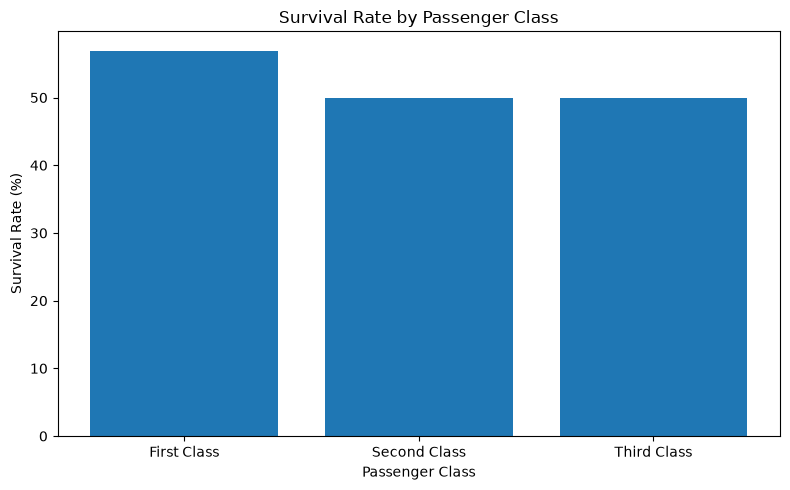

In [6]:
figure, axis = plt.subplots(figsize=(8, 5))

axis.bar(
    survival_by_class["PassengerClass"],
    survival_by_class["SurvivalRate"]
)

axis.set_title("Survival Rate by Passenger Class")
axis.set_xlabel("Passenger Class")
axis.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

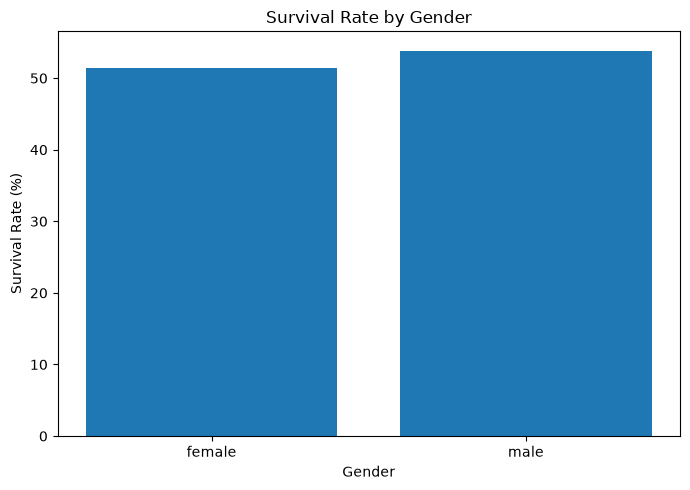

In [7]:
figure, axis = plt.subplots(figsize=(7, 5))

axis.bar(
    survival_by_gender["Sex"],
    survival_by_gender["SurvivalRate"]
)

axis.set_title("Survival Rate by Gender")
axis.set_xlabel("Gender")
axis.set_ylabel("Survival Rate (%)")
plt.tight_layout()
plt.show()

## 6. Compare age distribution by survival status

A boxplot is used to compare the age distribution of survivors and non-survivors.

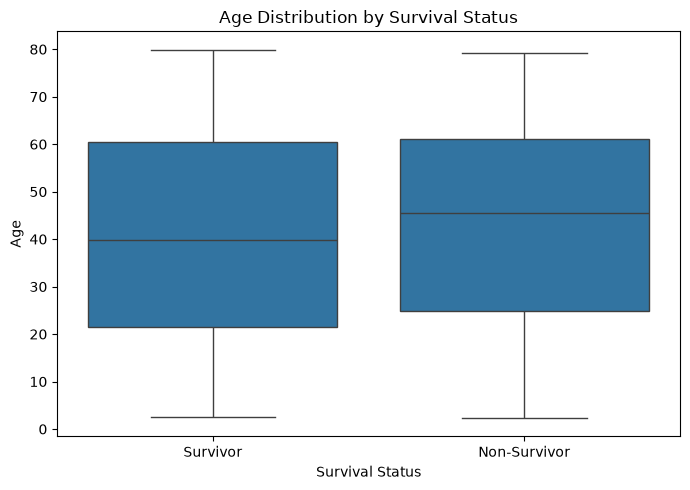

In [8]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=clean_titanic_data,
    x="SurvivalStatus",
    y="Age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## 7. Calculate the average age of survivors and non-survivors

The average age is calculated separately for both survival groups.

In [9]:
average_age_by_survival = (
    clean_titanic_data.groupby("SurvivalStatus")["Age"]
    .mean()
    .reindex(["Survivor", "Non-Survivor"])
)

average_age_survivors = average_age_by_survival["Survivor"]
average_age_non_survivors = average_age_by_survival["Non-Survivor"]

print(f"Average age of survivors: {average_age_survivors:.2f}")
print(f"Average age of non-survivors: {average_age_non_survivors:.2f}")

Average age of survivors: 41.10
Average age of non-survivors: 43.75


# Streamlit Web Application

Save the following code as `T4_app.py` in the same folder as `125M1H026_ADS_Ex_Lab_T4_A2`.

Run the application from PowerShell:

`python -m streamlit run .\T4_app.py`


## Conclusion

The dashboard cleans the dataset, converts numeric codes into readable labels, and compares survival patterns using passenger class, gender, and age. It also provides a direct comparison between the average age of survivors and non-survivors.